In [1]:
# This script is used for visualizations of all results (features, EEG, TRFs, predictions, comparison box-plots etc.)
# All lines where "TRF for Alice EEG Dataset" pipeline (cited in the thesis) is followed are commented with: "TRF for Alice EEG Dataset"

import pickle
from pathlib import Path
import pandas as pd
import numpy as np

from scipy import stats
from scipy.io import loadmat
from scipy.signal import resample

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

import mne
from mne.channels import make_dig_montage

import eelbrain
from eelbrain import combine

# Define paths that will be used throughout
DATA_ROOT = Path('/Users/zorkabozilovic/Desktop/PART1')
STIMULUS_DIR = DATA_ROOT / 'diliBach_wav_4dryad'
EEG_DIR = DATA_ROOT / 'diliBach_4dryad_CND'
RESULTS_RAW = DATA_ROOT / 'not improved results' # Pickle files
RESULTS_PROCESSED = DATA_ROOT / 'results' # Pickle files

# Load feature sets (raw and processed)
with open(DATA_ROOT / 'song_features.pkl', 'rb') as f:
    old_features = pickle.load(f)
with open(DATA_ROOT / 'improved_song_features.pkl', 'rb') as f:
    new_features = pickle.load(f)

# Load CSV with all TRF results
df = pd.read_csv(DATA_ROOT / 'all_trf_results.csv')

# Constants
BANDS = ['delta', 'theta', 'alpha', 'beta', 'wideband']
FEATURES_RAW = ['envelope', 'onsets', 'pitch', 'centroid', 'mel']
FEATURES_PROCESSED = ['envelope', 'onsets', 'pitch', 'centroid', 'mfcc3']
FEATURE_SR = 100 # Feature sampling rate
PIPELINES = ['not standardized', 'standardized']
TRIAL_COLS = [f'r_trial_{i}' for i in range(1, 31)] # Trial columns in the CSV file
FEAT_ORDERS = {
    'not standardized': ['envelope', 'onsets', 'pitch', 'centroid', 'mel'],
    'standardized':     ['envelope', 'onsets', 'pitch', 'centroid', 'mfcc3'],
} # Fixed feature order for both pipelines

In [2]:
# Exclude rows where boosting learned no TRF kernel (check checking_nans.ipynb for more details)
# Excluded are: Sub2 centroid decoding for alpha and beta and both pipelines, Sub19 pitch decoding for alpha and raw (not standardized) pipeline only

before = len(df)
df = df.dropna(subset=['mean_r'])
print(f'Excluded {before - len(df)} rows with NaN values')

Excluded 5 rows with NaN values


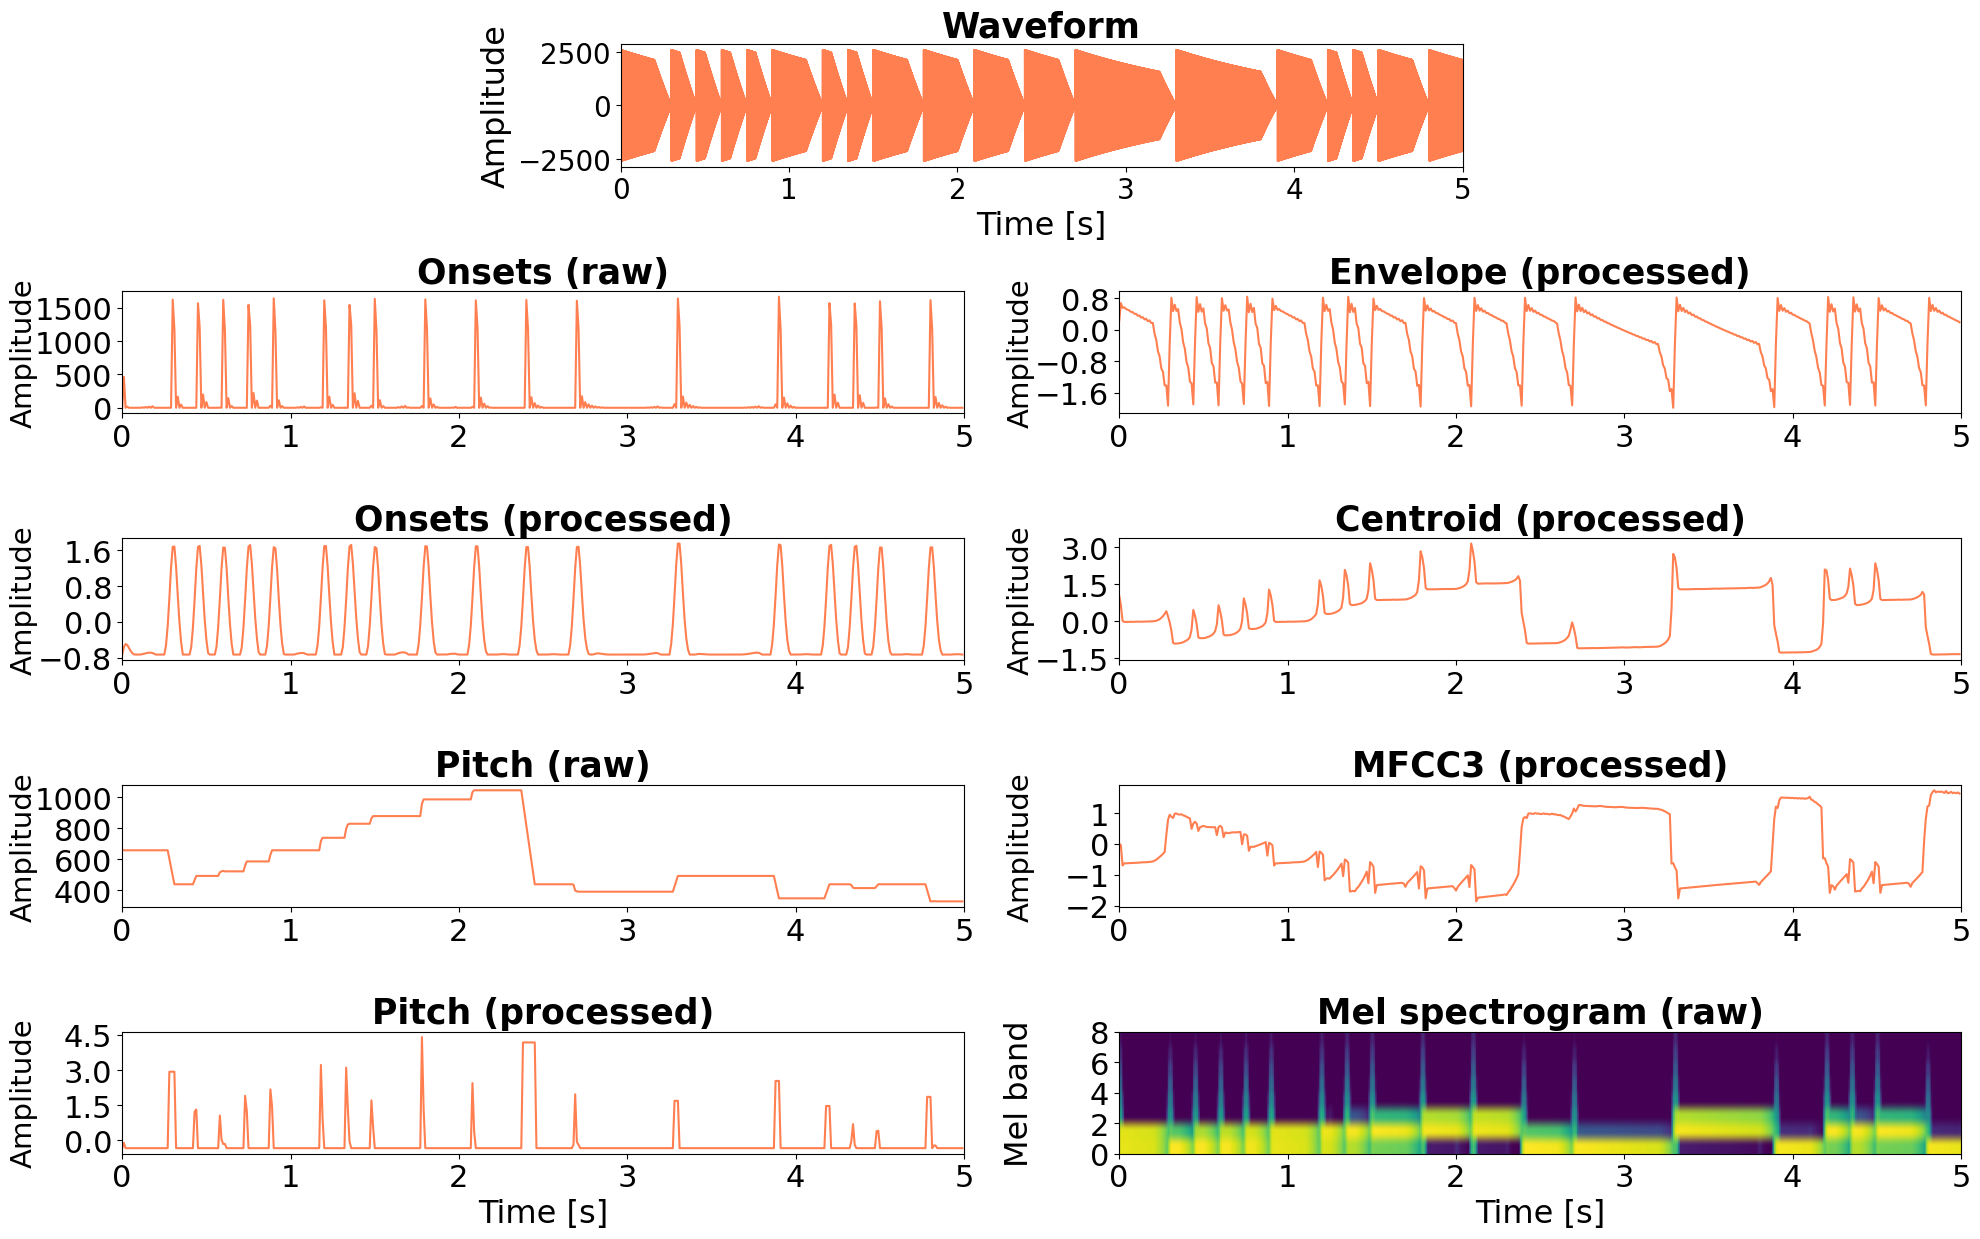

In [3]:
# Plot an example of a waveform and correspondnig acoustic features (song 2, first 5 seconds)

song_id = 2
end = 500  # 5 seconds at 100 Hz

panels = [ # (label, source dict, feature name, plot type)
    # Left column
    ('Onsets (raw)', old_features, 'onsets', 'line'),
    ('Onsets (processed)', new_features, 'onsets', 'line'),
    ('Pitch (raw)', old_features, 'pitch', 'line'),
    ('Pitch (processed)', new_features, 'pitch', 'line'),
    # Right column
    ('Envelope (processed)', new_features, 'envelope', 'line'),
    ('Centroid (processed)', new_features, 'centroid', 'line'),
    ('MFCC3 (processed)', new_features, 'mfcc3', 'line'),
    ('Mel spectrogram (raw)', old_features, 'mel', 'image'),
]


# Build the big figure: 5 rows × 2 cols (top row is the waveform only, spanning both columns, centered and the same width as the features)
fig = plt.figure(figsize=(20, 12.5)) # 2.5*5 inch tall
gs = gridspec.GridSpec(5, 4, figure=fig) # 4 sub-columns so waveform can take 2 middle columns
wav_ax = fig.add_subplot(gs[0, 1:3]) # centered and half width of the whole figure for waveform

feature_axes = []
for row in range(1, 5):
    feature_axes.append([
        fig.add_subplot(gs[row, 0:2]), # left feature column
        fig.add_subplot(gs[row, 2:4]), # right feature column
    ])


# Waveform plot
wav = eelbrain.load.wav(STIMULUS_DIR / f'{song_id}.wav')
wav_data = wav.x # use numpy
wav_end = int(5 / wav.time.tstep) # nubmber of samples in 5 seconds
wav_ax.plot(np.arange(wav_end) * wav.time.tstep, wav_data[:wav_end], color='coral')
wav_ax.set_xlim(0, 5) # delete gaps before 0s and after 5s
# Labels
wav_ax.set_ylabel('Amplitude', fontsize=23)
wav_ax.set_xlabel('Time [s]', fontsize=23)
wav_ax.set_title('Waveform', fontsize=25, fontweight='bold')
wav_ax.tick_params(axis='both', labelsize=20)


# Feature plots
for i, (title, source, name, kind) in enumerate(panels):
    col = i // 4 # plotting 8 features in total so first 4 go in the first column (column 0)
    row = i % 4 # fillings rows 0, 1, 2 and 3
    ax = feature_axes[row][col]

    if kind == 'line': # all except mel
        data = source[song_id][name].x[:end] # 500 samples
        t = np.arange(len(data)) / FEATURE_SR # 500 time points
        ax.plot(t, data, color='coral', linewidth=1.5)
        ax.set_ylabel('Amplitude', fontsize=21)

    else: # mel
        mel = source[song_id][name].x[:end]
        ax.imshow(mel.T, aspect='auto', origin='lower', extent=[0, 5, 0, mel.shape[1]])
        ax.set_ylabel('Mel band', fontsize=23)
    
    # Labels
    ax.set_title(title, fontsize=25, fontweight='bold')
    ax.tick_params(axis='both', labelsize=22)

    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4, min_n_ticks=4)) # set at least 4 and at most 5 ticks
    ax.set_xlim(0, 5) # delete gaps before 0s and after 5s

# Show Time [s] only on bottom row
feature_axes[-1][0].set_xlabel('Time [s]', fontsize=23)
feature_axes[-1][1].set_xlabel('Time [s]', fontsize=23)


plt.tight_layout()

# Align all y-labels to the same horizontal position (running it after tight_layout so they do not move)
POSITION_X = -0.1
for ax in [a for row in feature_axes for a in row]: # all plots except waveform
    ax.yaxis.set_label_coords(POSITION_X, 0.5)

plt.show()

# Save as a pdf for the thesis
fig.savefig(DATA_ROOT / 'features_example.pdf', bbox_inches='tight')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 64


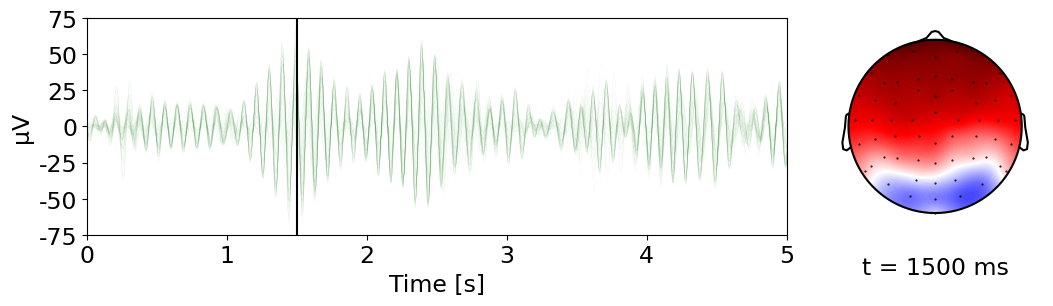

In [4]:
# Plot an example of EEG butterfly plot (for Sub19 alpha band and first trial)
# Use the same funcitons used in the pipelines

SUBJECT = 'Sub19'
LOW_FREQUENCY = 8
HIGH_FREQUENCY = 12


# Load EEG data from one subject
def load_subject_raw_eeg(filepath, subject):
    
    # Extract subject index from string (e.g., 'Sub18' -> 18)
    subject_idx = int(subject[3:])
        
    # Load the .mat file
    mat_data = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    eeg = mat_data["eeg"]
    target_fs = 500  # sampling frequency
    orig_fs = int(eeg.fs)
    resample_needed = orig_fs != target_fs
    for i in range(len(eeg.data)):
        
        # Scale data 
        trial_data = 100 * eeg.data[i].astype(np.float32) / np.iinfo(np.int32).max
        
        # Resample to 500Hz, to be consistent with the "TRF for Alice EEG Dataset" pipeline
        if resample_needed:
            n_samples = int(trial_data.shape[0] * target_fs / orig_fs)
            trial_data = resample(trial_data, n_samples, axis=0)
        
        eeg.data[i] = trial_data
        
    # Extract key information into a dictionary
    raw_data = {
        'trials': eeg.data,
        'fs': target_fs,
        'chanlocs': eeg.chanlocs,
        'pad_start': int(eeg.paddingStartSample * target_fs / orig_fs) if resample_needed else int(eeg.paddingStartSample),
        'subject_type': 'Musician' if subject_idx >= 11 else 'Non-musician'
    }
    
    # print(f"Loaded {raw_data['subject_type']} (Subject {subject})") - no need for printing here
    # print(f"  - {len(raw_data['trials'])} trials, {raw_data['trials'][0].shape[1]} channels") - no need for printing here
    
    return raw_data


# Convert already-loaded Bach data to MNE Raw object with channel positions
def create_mne_raw_from_loaded(subject_data):
    
    trials = subject_data['trials']
    sfreq = subject_data['fs']
    pad_start = subject_data['pad_start']    
    chanlocs = subject_data['chanlocs']
    
    # Get channel names and positions
    ch_names = []
    positions = []
    
    for ch in chanlocs:
        
        # Get channel label        
        ch_names.append(ch.labels)
        
        # Get channel positions if available
        if hasattr(ch, 'X') and hasattr(ch, 'Y') and hasattr(ch, 'Z'):
            positions.append([ch.Y, ch.X, ch.Z])
    
    # Concatenate all trials
    all_trials = []
    trial_lengths = []
    
    for trial in trials:
        # Remove padding and transpose to channels x time
        trial_clean = trial[pad_start:, :].T
        all_trials.append(trial_clean)
        trial_lengths.append(trial_clean.shape[1])
    
    # Concatenate
    eeg_continuous = np.hstack(all_trials)
    n_channels, n_samples = eeg_continuous.shape
    
    # Create stimulus channel with trial markers
    stim_data = np.zeros((1, n_samples))
    
    # Mark all 30 trial onsets
    current_sample = 0
    marker_positions = []
    for i in range(30):
        # Place marker at current position (offset by 1 if at sample 0)
        marker_sample = 1 if current_sample == 0 else current_sample
        stim_data[0, marker_sample] = i + 1 # Use 1-30 as event IDs
        marker_positions.append((i+1, marker_sample))
        current_sample += trial_lengths[i] # Move to next trial start
        
    # Combine EEG and stim
    data_with_stim = np.vstack([eeg_continuous, stim_data])
    
    # Channel setup
    ch_names = ch_names + ['STI']
    ch_types = ['eeg'] * n_channels + ['stim']
    
    # Create Raw
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data_with_stim, info, verbose=False) # no need for printing here
        
    montage = make_dig_montage(
        ch_pos=dict(zip(ch_names[:n_channels], positions)),
        coord_frame='head'
    )
    raw.set_montage(montage)
    return raw


# Load EEG once for this subject
eeg_data = load_subject_raw_eeg(EEG_DIR / f'data{SUBJECT}.mat', SUBJECT)

# Filter EEG and create events
raw = create_mne_raw_from_loaded(eeg_data)
raw.filter(LOW_FREQUENCY, HIGH_FREQUENCY, n_jobs=1, verbose=False) # Follow "TRF for Alice EEG Dataset" pipeline


# Plot topographic EEG butterfly plot
p = eelbrain.plot.TopoButterfly(raw, t=1.5, xlim=[0, 5], vmax=0.75e-4, h=3, w=10, clip='circle') # Follow "TRF for Alice EEG Dataset" pipeline

# Make vertical time cursor black and tick and all channel lines blue and thin
butterfly_ax = p.axes[0]
for line in butterfly_ax.get_lines():
    xdata = line.get_xdata() 
    if len(xdata) == 2 and xdata[0] == xdata[1]: # Time cursor (used for topo map)
        line.set_color('black')
        line.set_linewidth(1.5)
    else:
        line.set_color('forestgreen')
        line.set_linewidth(0.01)

# Increase font size
for text in p.figure.findobj(plt.Text):
    text.set_fontsize(17)
        
# Shift topomap slightly to the right
pos = p.axes[1].get_position()
p.axes[1].set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])


# Save as a pdf for the thesis (pdf version is much sharper than the plot below)
p.figure.savefig(DATA_ROOT / 'eeg_example.pdf', bbox_inches='tight')

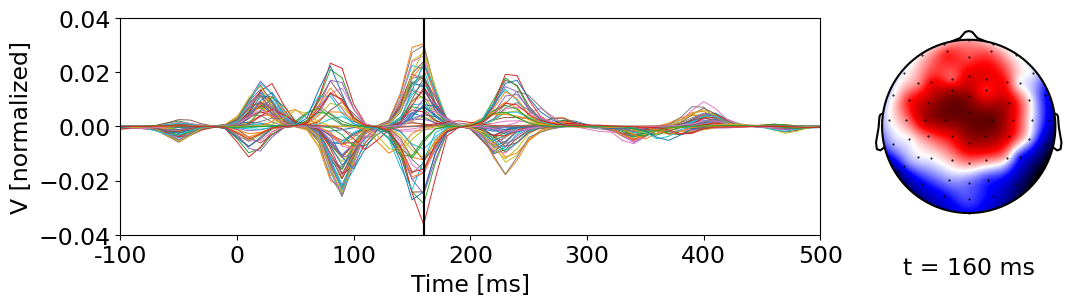

In [5]:
# Plot an example of encoding TRF (Sub13 theta band for envelope with processed pipeline)

SUBJECT = 'Sub13'
BAND = 'theta'
FEATURE = 'envelope'

with open(RESULTS_PROCESSED / f'{SUBJECT}_{BAND}.pkl', 'rb') as f:
    data = pickle.load(f)

# Get encoding TRF
encoder_h = data['encode_results'][FEATURE]['model'].h
t_enc = encoder_h.std('sensor').argmax('time') # Used for time cursor and topomap (follow "TRF for Alice EEG Dataset" pipeline)

# Plot topographic TRF butterfly plot
p = eelbrain.plot.TopoButterfly(encoder_h, t=t_enc, xlim=[-0.100, 0.500], h=3, w=10, clip='circle')

# Make vertical time cursor black and tick and all channel lines blue and thin
butterfly_ax = p.axes[0]
for line in butterfly_ax.get_lines():
    xdata = line.get_xdata() 
    if len(xdata) == 2 and xdata[0] == xdata[1]: # Time cursor
        line.set_color('black')
        line.set_linewidth(1.5)
    else:
        line.set_linewidth(0.7)

# Increase font size
for text in p.figure.findobj(plt.Text):
    text.set_fontsize(17)
    
# Shift topomap slightly to the right
pos = p.axes[1].get_position()
p.axes[1].set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save as a pdf for the thesis (pdf version is much sharper than the plot below)
p.figure.savefig(DATA_ROOT / 'encoding_TRF_example.pdf', bbox_inches='tight')

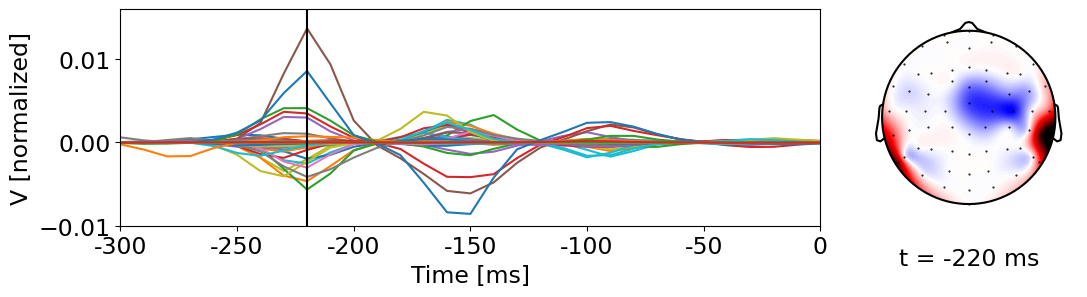

In [6]:
# Plot an example of decoding TRF (musicians average theta band for envelope with processed pipeline)

MUSICIANS = [f'Sub{i}' for i in range(11, 21)]
BAND = 'theta'
FEATURE = 'envelope'

# Load decoders from all musicians
decoders = []
for sub in MUSICIANS:
    with open(RESULTS_PROCESSED / f'{sub}_{BAND}.pkl', 'rb') as f:
        data = pickle.load(f)
    decoders.append(data['decode_results'][FEATURE]['model'].h)

# Average across musicians
trf_avg = combine(decoders).mean('case')
t_dec = trf_avg.std('sensor').argmax('time') # Used for time cursor and topomap (follow "TRF for Alice EEG Dataset" pipeline)
max_val = abs(trf_avg).max() # Used for max and min value below

# Plot topographic TRF butterfly plot
p = eelbrain.plot.TopoButterfly(trf_avg, t=t_dec, xlim=[-0.300, 0.000], h=3, w=10, clip='circle', vmax=max_val, vmin=-max_val)
# Fix y axis
p.set_ylim(-0.010, 0.016)
butterfly_ax = p.axes[0]
butterfly_ax.set_ylabel('V [normalized]', fontsize=17)
butterfly_ax.set_yticks([-0.01, 0.00, 0.01])

# Increase font size
for text in p.figure.findobj(plt.Text):
    text.set_fontsize(17)

# Shift topomap slightly to the right
pos = p.axes[1].get_position()
p.axes[1].set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save as a pdf for the thesis (pdf version is much sharper than the plot below)
p.figure.savefig(DATA_ROOT / 'decoding_TRF_example.pdf', bbox_inches='tight')

In [7]:
# Find the best, median and worst r-values per feature for song 2 (for theta band decoding)

allowed_trials = [2, 12, 22] # song 2

# Find all r's from trials 2, 12 and 22
def collect_trials(pipeline, feature):
    sub = df[(df['pipeline'] == pipeline) &
             (df['band'] == 'theta') &
             (df['direction'] == 'decoding') &
             (df['combo_name'] == feature)]
    rows = []
    for _, row in sub.iterrows():
        for t in allowed_trials:
            r = row[f'r_trial_{t}']
            rows.append({'subject': row['subject'], 'trial': t, 'r': r})
    return pd.DataFrame(rows)

# Find best, median and worst r's by sorting all values
def best_median_worst(trial_df):
    sorted_df = trial_df.sort_values('r').reset_index(drop=True)
    n = len(sorted_df)
    return sorted_df.iloc[0], sorted_df.iloc[n // 2], sorted_df.iloc[-1]

# Print the values found
def print_rs(feat, pipeline, pipeline_label):
    worst, median, best = best_median_worst(collect_trials(pipeline, feat))
    print(f"{feat:<12} {pipeline_label:<14} {'best':<10} {best['subject']:<12} {int(best['trial']):>4}    {best['r']:>7.4f}")
    print(f"{'':<12} {'':<14} {'median':<10} {median['subject']:<12} {int(median['trial']):>4}    {median['r']:>7.4f}")
    print(f"{'':<12} {'':<14} {'worst':<10} {worst['subject']:<12} {int(worst['trial']):>4}    {worst['r']:>7.4f}")
    print()

# Header
print(f"{'Feature':<12} {'Pipeline':<14} {'Type':<10} {'Subject':<12} {'Trial':>4}   {'r':>7}")
print("-" * 68)

# Processed features
for feat in FEATURES_PROCESSED: # defined in cell 0
    print_rs(feat, 'standardized', 'processed')

# Mel from raw pipeline
print_rs('mel', 'not standardized', 'raw')

Feature      Pipeline       Type       Subject      Trial         r
--------------------------------------------------------------------
envelope     processed      best       Sub16           2     0.4425
                            median     Sub20          22     0.2437
                            worst      Sub2            2    -0.0201

onsets       processed      best       Sub16           2     0.5008
                            median     Sub8           22     0.2551
                            worst      Sub7           22    -0.0077

pitch        processed      best       Sub16           2     0.2656
                            median     Sub19           2     0.1466
                            worst      Sub7           22    -0.0044

centroid     processed      best       Sub16           2     0.1559
                            median     Sub19           2     0.0760
                            worst      Sub2           12    -0.0088

mfcc3        processed      best       Sub1

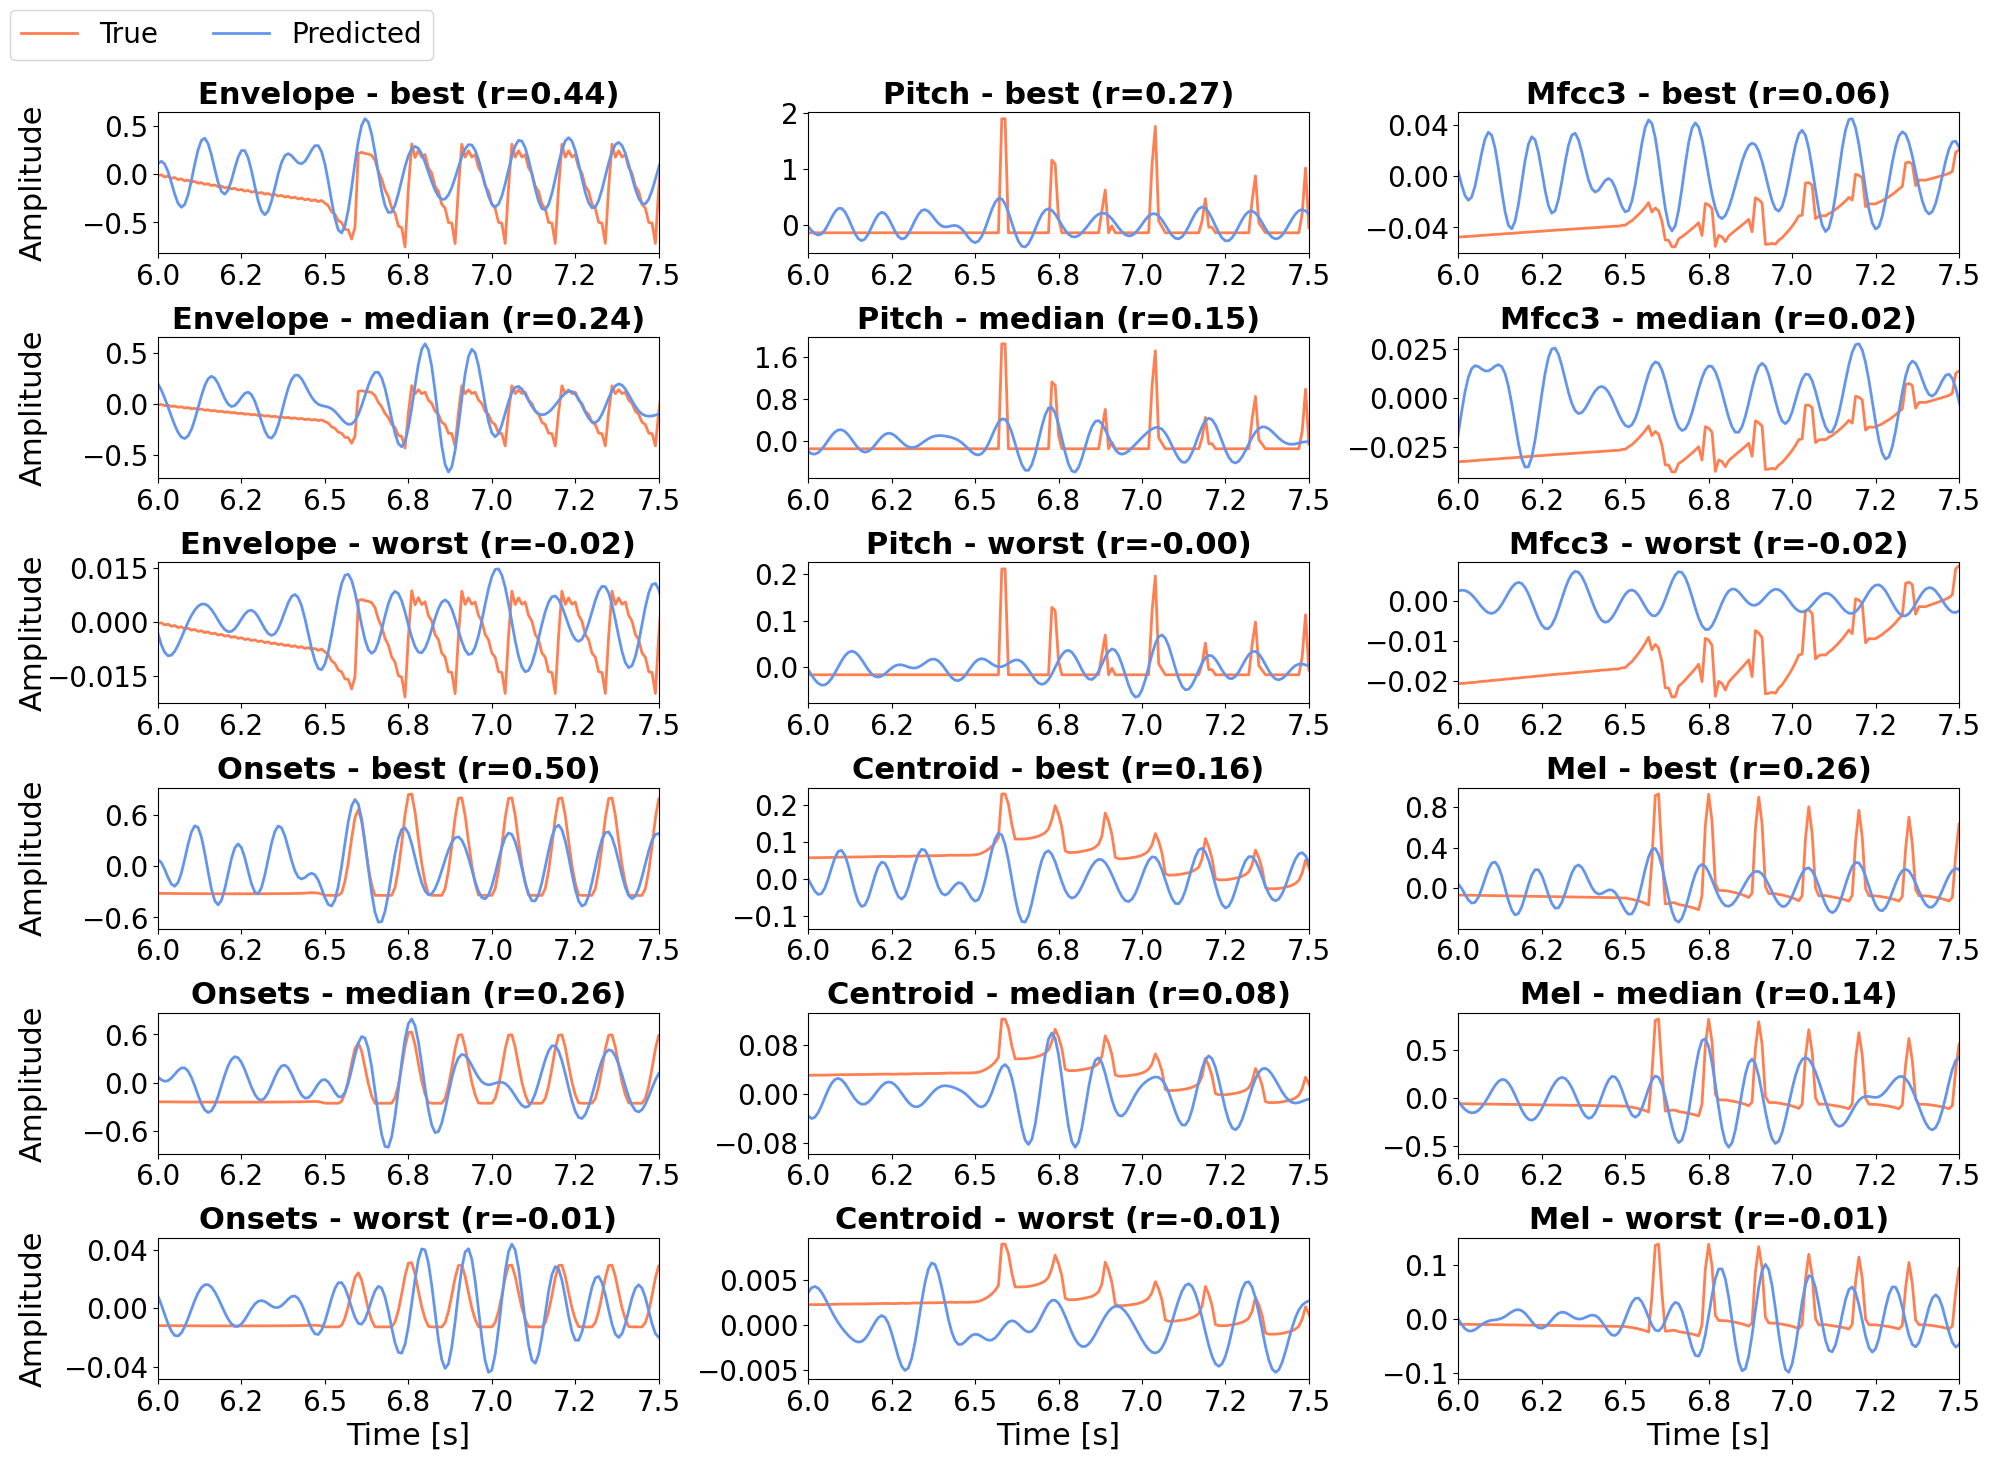

In [8]:
# Plot examples of the best, median, and the worst decoding reconstructions per feature for song 2 (1.5s shown) and theta band

pipeline_dir = {'standardized': RESULTS_PROCESSED, 'not standardized': RESULTS_RAW}

# 6 rows × 3 columns: each column shows 2 features with 3 plots each (order: best, median, worst)
panels = [
    # Column 0: envelope and onsets
    (0, 0, 'envelope', 'best',   'standardized'),
    (0, 1, 'envelope', 'median', 'standardized'),
    (0, 2, 'envelope', 'worst',  'standardized'),
    (0, 3, 'onsets',   'best',   'standardized'),
    (0, 4, 'onsets',   'median', 'standardized'),
    (0, 5, 'onsets',   'worst',  'standardized'),
    # Column 1: pitch and centroid
    (1, 0, 'pitch',    'best',   'standardized'),
    (1, 1, 'pitch',    'median', 'standardized'),
    (1, 2, 'pitch',    'worst',  'standardized'),
    (1, 3, 'centroid', 'best',   'standardized'),
    (1, 4, 'centroid', 'median', 'standardized'),
    (1, 5, 'centroid', 'worst',  'standardized'),
    # Column 2: mfcc3 and mel (only raw)
    (2, 0, 'mfcc3',    'best',   'standardized'),
    (2, 1, 'mfcc3',    'median', 'standardized'),
    (2, 2, 'mfcc3',    'worst',  'standardized'),
    (2, 3, 'mel',      'best',   'not standardized'),
    (2, 4, 'mel',      'median', 'not standardized'),
    (2, 5, 'mel',      'worst',  'not standardized'),
]

allowed_trials = [2, 12, 22] # song 2

# Using functions from the cell above
def find_entry(pipeline, feature, kind):
    # Find all r's from trails 2, 12 and 22
    sub = df[(df['pipeline'] == pipeline) &
             (df['band'] == 'theta') &
             (df['direction'] == 'decoding') &
             (df['combo_name'] == feature)]
    rows = []
    for _, row in sub.iterrows():
        for t in allowed_trials:
            r = row[f'r_trial_{t}']
            rows.append({'subject': row['subject'], 'trial': t, 'r': r})
    # Find best, median and worst r's by sorting all values
    sorted_df = pd.DataFrame(rows).sort_values('r').reset_index(drop=True)
    n = len(sorted_df)
    if kind == 'worst':  return sorted_df.iloc[0] # return worst
    if kind == 'median': return sorted_df.iloc[n // 2] # return median (return upper value)
    return sorted_df.iloc[-1] # return best

# Get reconstructed features from pickle files
def get_y_ypred(subject, trial, feature, pipeline):
    folder = pipeline_dir[pipeline]
    with open(folder / f'{subject}_theta.pkl', 'rb') as f:
        data = pickle.load(f)
    trial_key = f'trial{trial - 1}'  # CSV is 1-indexed (first is trial1), pickle is 0-indexed (first is trial0)
    return data['decode_results'][feature]['trials'][trial_key]

# Build the big figure
fig, axes = plt.subplots(6, 3, figsize=(20, 14))

# Build each subplot
for col, row, feature, kind, pipeline in panels:
    # Get trial's info
    entry = find_entry(pipeline, feature, kind)
    subject = entry['subject']
    trial = int(entry['trial'])
    r = entry['r']

    # Get true and predicted values for one trial
    trial_data = get_y_ypred(subject, trial, feature, pipeline)
    y = trial_data['y']
    y_pred = trial_data['y_pred']
    
    # For mel, average across bands to get 1D to match other features
    if feature == 'mel':
        y_x = y.mean('frequency').x
        y_pred_x = y_pred.mean('frequency').x
    else:
        y_x = y.x
        y_pred_x = y_pred.x
    
    # Slice the visible window (6-7.5s)
    start_idx = int(6 * FEATURE_SR)
    end_idx = int(7.5 * FEATURE_SR)
    y_window = y_x[start_idx:end_idx]
    y_pred_window = y_pred_x[start_idx:end_idx]
    
    # Make time axis
    t = np.arange(len(y_x)) / FEATURE_SR # number of samples / sampling rate

    # Plot true and predicted features
    ax = axes[row, col]
    ax.plot(t, y_x, color='coral', linewidth=2, label='True')
    ax.plot(t, y_pred_x, color='cornflowerblue', linewidth=2, label='Predicted')
    
    # For each subplot set y axis limits so that the features fill the whole panel
    combined_min = min(y_window.min(), y_pred_window.min())
    combined_max = max(y_window.max(), y_pred_window.max())
    margin = 0.05 * (combined_max - combined_min)
    ax.set_ylim(combined_min - margin, combined_max + margin)

    # Set at least 3 and at most 4 ticks for y axis
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3, min_n_ticks=3))

    # Labels
    ax.set_title(f"{feature.capitalize()} - {kind} (r={r:.2f})", fontsize=22, fontweight='bold')
    ax.tick_params(axis='both', labelsize=20)
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    # Delete gaps before 6s and after 7.5s
    ax.set_xlim(6, 7.5)

    # Add y axis labels only on the first column
    if col == 0:
        ax.set_ylabel('Amplitude', fontsize=22)

    # Add x axis labels only on the bottom row
    if row == 5:
        ax.set_xlabel('Time [s]', fontsize=22)

# Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, fontsize=20, bbox_to_anchor=(0, 1.05))

plt.tight_layout()

# Align all y-labels to the same horizontal position (running it after tight_layout so they do not move)
POSITION_X = -0.22
for row in range(6):
    axes[row, 0].yaxis.set_label_coords(POSITION_X, 0.5)

plt.show()

# Save as a pdf for the thesis
fig.savefig(DATA_ROOT / 'reconstruction_examples.pdf', bbox_inches='tight')

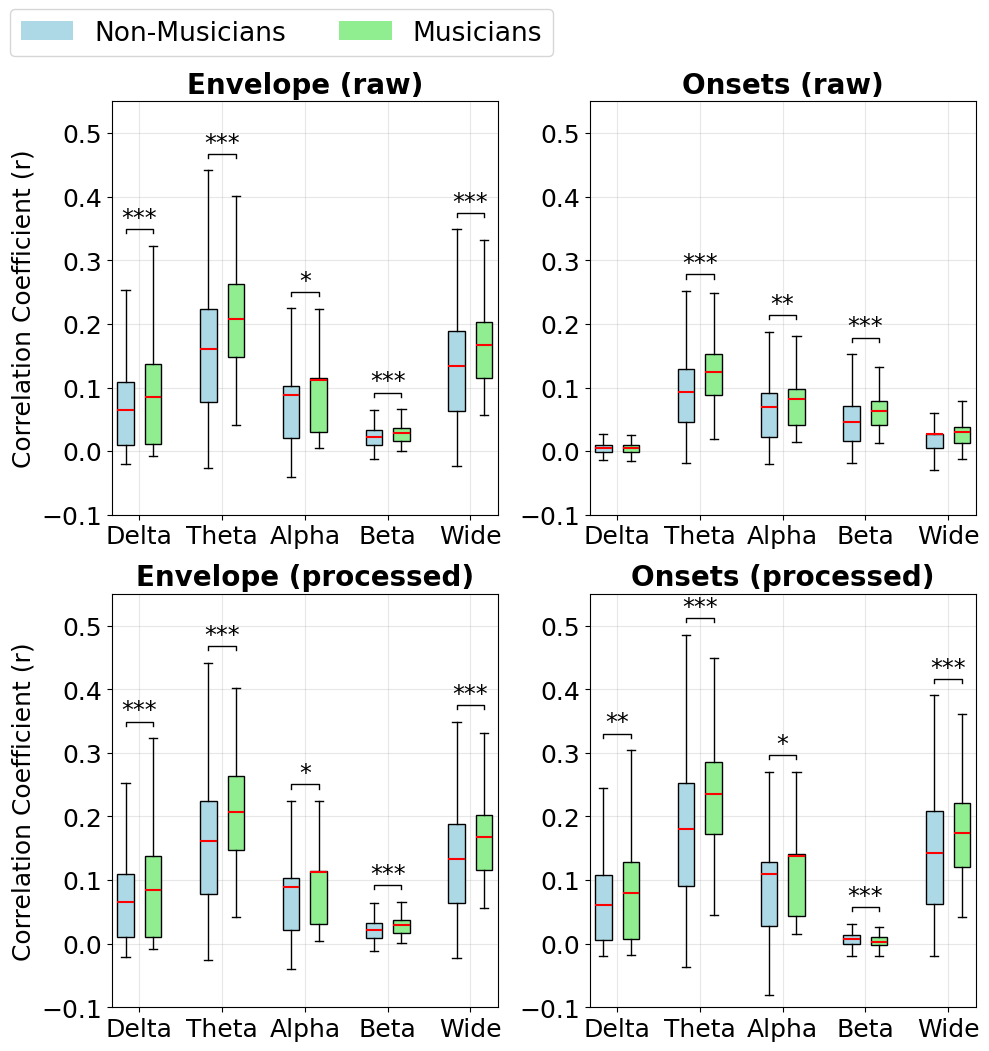

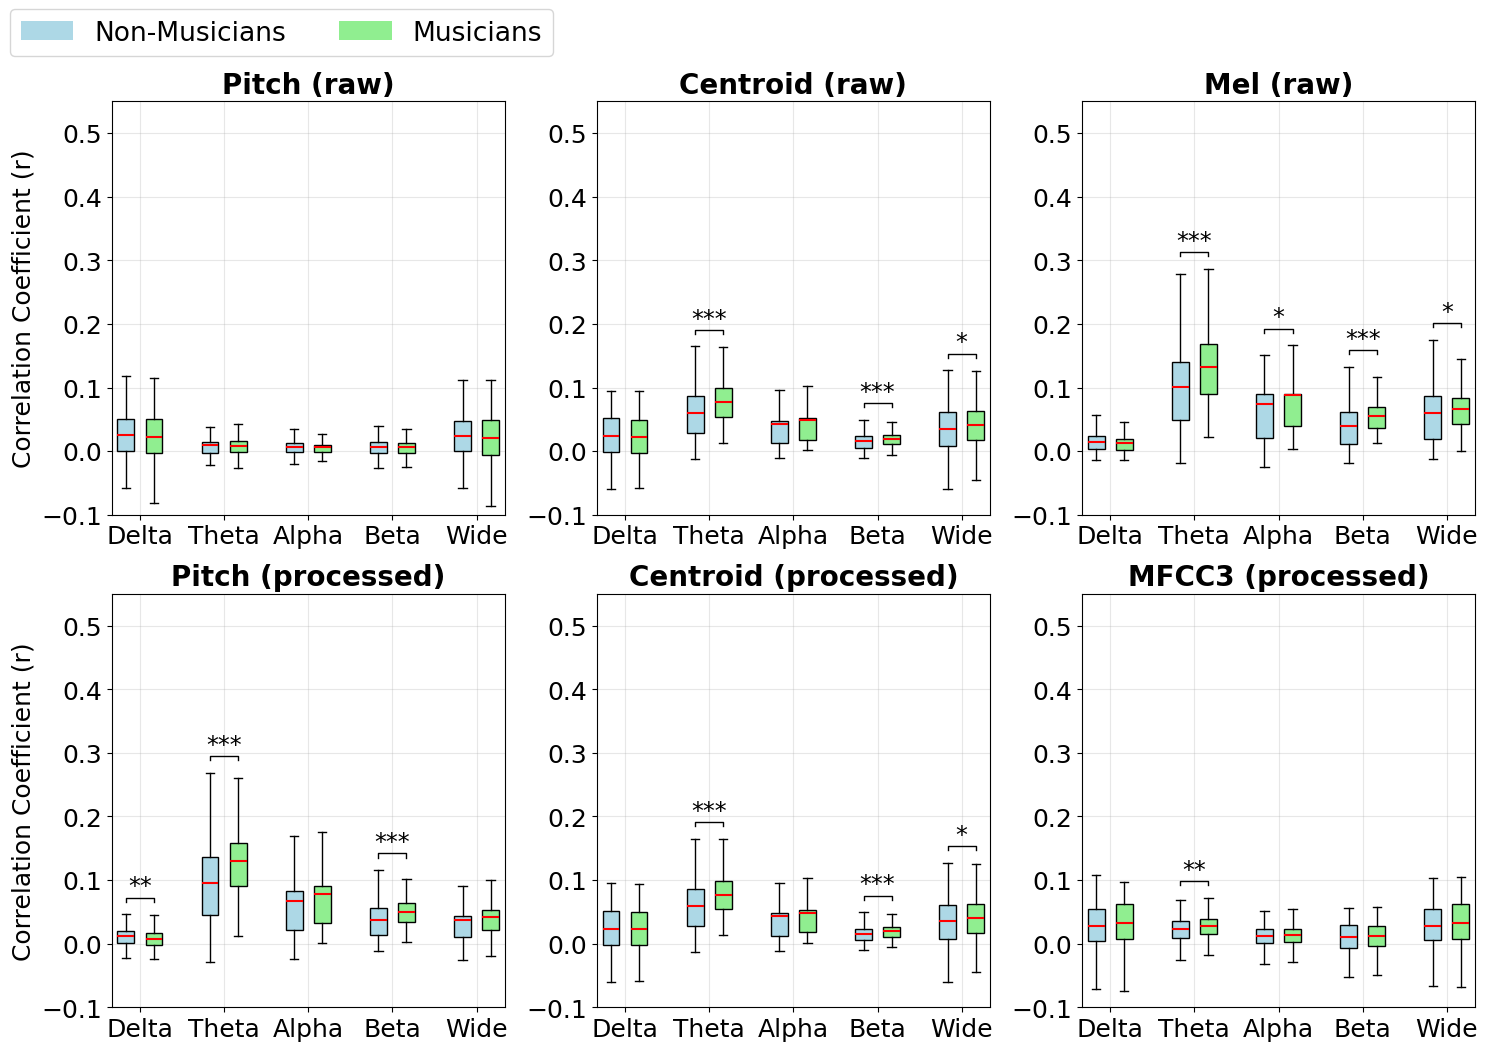

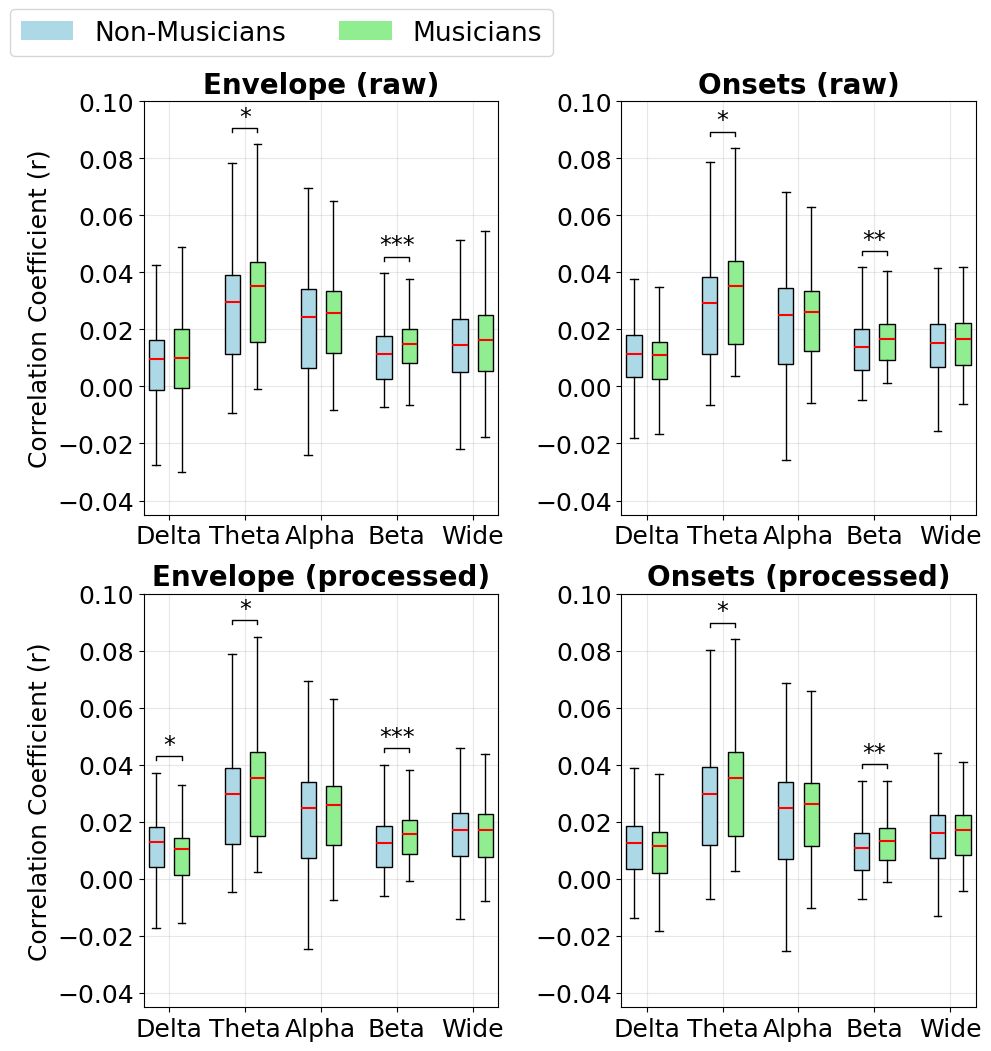

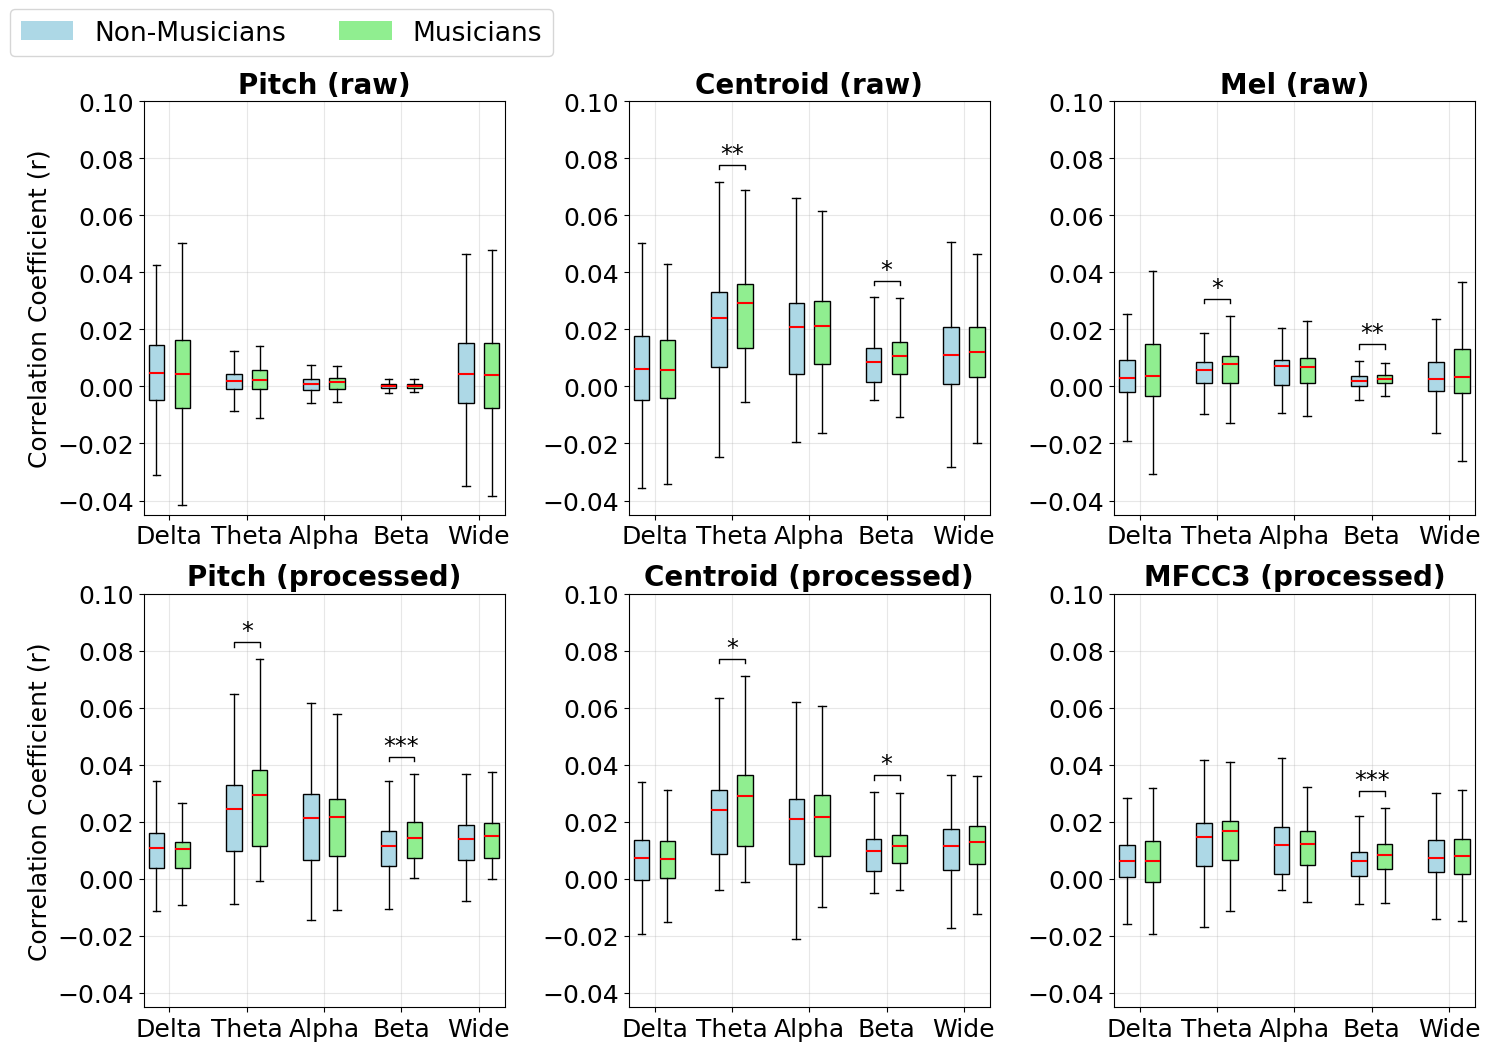

In [9]:
# Group comparison boxplots musicians vs non-musicians across single features (for both encoding and decoding per bands and pipeline)

# Split features into two groups so each figure stays readable in the thesis
feat_groups = {
    'first':  ['envelope', 'onsets'],
    'second': ['pitch', 'centroid', 'mfcc3', 'mel'],
}

# All encoidng (and decoding) boxplots should have the same y-axis limits for fair comparison across pipelines and features
ylims = {
    'decoding': (-0.1, 0.55),
    'encoding': (-0.045, 0.1),
}

for direction in ['decoding', 'encoding']:
    for group_name, group_feats in feat_groups.items():
        
        # Figure size (columns) scales with number of features in this group
        n_cols = max(
            sum(1 for f in FEAT_ORDERS[p] if f in group_feats)
            for p in PIPELINES
        )
        
        fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))

        # Used to scale offset of significance brackets and stars
        y_range = ylims[direction][1] - ylims[direction][0]
        
        for row_idx, pipeline in enumerate(PIPELINES):

            # Use current direction and pipeline
            dir_df = df[(df['direction'] == direction) & (df['pipeline'] == pipeline)]

            # Pick features for this group and keep them in the correct order
            feats = [f for f in FEAT_ORDERS[pipeline] if f in group_feats and f in dir_df['combo_name'].values]
            
            for feat_idx, feat in enumerate(feats):
                
                # Pick the panel for this pipeline and feature pair
                ax = axes[row_idx, feat_idx]
                
                for i, band in enumerate(BANDS):
                    band_df = dir_df[(dir_df['combo_name'] == feat) & (dir_df['band'] == band)]

                    # Non-musician values
                    nm_vals = band_df[band_df['group'] == 'Non-musician'][TRIAL_COLS].values.flatten()

                    # Musician values
                    m_vals = band_df[band_df['group'] == 'Musician'][TRIAL_COLS].values.flatten()

                    # Boxplot for non-musicians
                    bp1 = ax.boxplot([nm_vals], positions=[i*3], widths=0.6, patch_artist=True,
                                     showfliers=False, medianprops=dict(visible=False))
                    bp1['boxes'][0].set_facecolor('lightblue')
                    # Add mean
                    ax.hlines(np.mean(nm_vals), i*3-0.3, i*3+0.3, colors='red', linewidth=1.5)

                    # Boxplot for musicians
                    bp2 = ax.boxplot([m_vals], positions=[i*3+1], widths=0.6, patch_artist=True,
                                     showfliers=False, medianprops=dict(visible=False))
                    bp2['boxes'][0].set_facecolor('lightgreen')
                    # Add mean
                    ax.hlines(np.mean(m_vals), i*3+1-0.3, i*3+1+0.3, colors='red', linewidth=1.5)

                    # Calculae p values
                    t_stat, p_value = stats.ttest_ind(nm_vals, m_vals)
                    if p_value < 0.05:
                        # Pick the taller whisker for each band so that the bracket sit above the taller one
                        whisker_max_nm = bp1['whiskers'][1].get_ydata()[1]
                        whisker_max_m = bp2['whiskers'][1].get_ydata()[1]
                        max_whisker = max(whisker_max_nm, whisker_max_m)
                        y_pos = max_whisker + y_range * 0.04
                        
                        # Add brackets
                        ax.plot([i*3, i*3, i*3+1, i*3+1],
                                    [y_pos - y_range * 0.01, y_pos, y_pos, y_pos - y_range * 0.01],'k-', linewidth=1)
                        # Add stars
                        stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
                        ax.text(i*3+0.5, y_pos, stars, ha='center', va='bottom', fontsize=17)

                # Set tick labels
                ax.set_ylim(ylims[direction])
                ax.tick_params(axis='y', labelsize=18)
                ax.set_xticks([i*3+0.5 for i in range(len(BANDS))])
                ax.set_xticklabels(['Wide' if b == 'wideband' else b.capitalize() for b in BANDS], fontsize=18)

                # Set titles
                pipeline_label = 'processed' if pipeline == 'standardized' else 'raw'
                feat_name = 'MFCC3' if feat == 'mfcc3' else feat.capitalize()
                ax.set_title(f'{feat_name} ({pipeline_label})', fontsize=20, fontweight='bold')

                # Faint grid
                ax.grid(True, alpha=0.3)

                # Add y axis labels only on the first column
                if feat_idx == 0:
                    ax.set_ylabel('Correlation Coefficient (r)', fontsize=18)
        
        # Single legend per figure in top left of the figure
        legend_elements = [Patch(facecolor='lightblue', label='Non-Musicians'), Patch(facecolor='lightgreen', label='Musicians')]
        fig.legend(handles=legend_elements, loc='upper left', ncol=2, fontsize=19, bbox_to_anchor=(0.0, 1.06))
        
        plt.tight_layout()

        # Save as a pdf for the thesis
        fig.savefig(DATA_ROOT / f'one_feature_{direction}_{group_name}.pdf', bbox_inches='tight')
        
        plt.show()

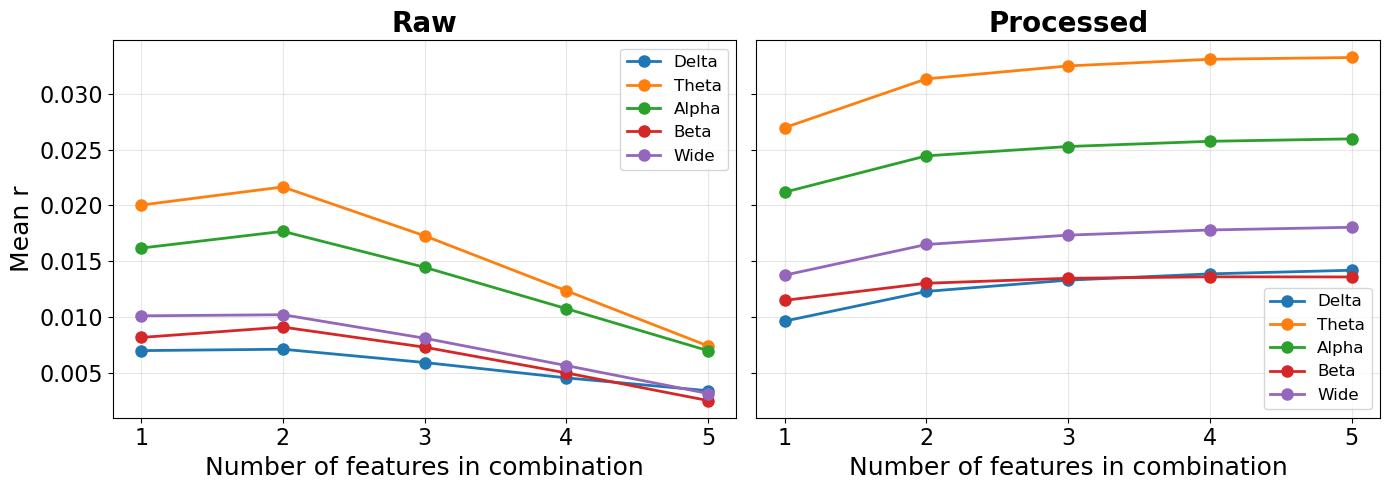

In [10]:
# Plot mean r per band as the number of combined features in encoding increases (for both pipelines)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for col_idx, pipeline in enumerate(PIPELINES):
    
    ax = axes[col_idx]
    enc_df = df[(df['direction'] == 'encoding') & (df['pipeline'] == pipeline)]

    # Draw one line per band
    for band in BANDS:
        
        band_df = enc_df[enc_df['band'] == band]
        
        # For each number of features compute mean r across all combos of that size
        mean_per_n = []
        for n in range(1, 6):
            n_df = band_df[band_df['n_features'] == n]
            vals = n_df[TRIAL_COLS].values.flatten() # 1D array
            mean_per_n.append(np.mean(vals))

        # Make wideband shorter for the legend
        label = 'Wide' if band == 'wideband' else band.capitalize()

        # One line per band
        ax.plot(range(1, 6), mean_per_n, marker='o', linewidth=2, markersize=8, label=label)

    # Add titles
    pipeline_label = 'processed' if pipeline == 'standardized' else 'raw'
    ax.set_title(pipeline_label.capitalize(), fontsize=20, fontweight='bold')

    # Set x-axis and tick labels
    ax.set_xlabel('Number of features in combination', fontsize=18)
    ax.set_xticks(range(1, 6))
    ax.tick_params(axis='both', labelsize=16)
    
    # Faint grid
    ax.grid(True, alpha=0.3)

    # Fix legend font size
    ax.legend(fontsize=12, loc='best')

# y axis label only on the first column
axes[0].set_ylabel('Mean r', fontsize=18)

plt.tight_layout()

# Save as a pdf for the thesis
fig.savefig(DATA_ROOT / 'encoding_mean_r_per_n.pdf', bbox_inches='tight')

plt.show()

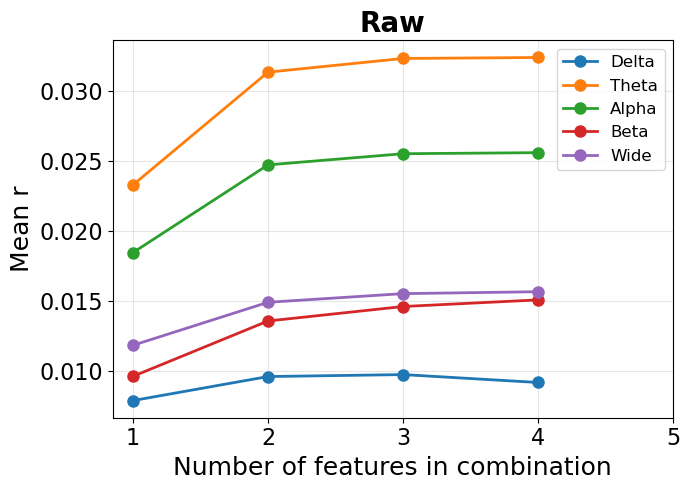

In [11]:
# Plot mean r per band as the number of combined features in encoding increases (raw pipeline, mel excluded)

fig, ax = plt.subplots(figsize=(7, 5))

enc_df = df[(df['direction'] == 'encoding') & (df['pipeline'] == 'not standardized')]

# Exclude any combination containing mel
enc_df = enc_df[~enc_df['combo_name'].str.contains('mel')]

# Draw one line per band
for band in BANDS:
    
    band_df = enc_df[enc_df['band'] == band]
    
    # For each number of features compute mean r across all combos of that size
    mean_per_n = []
    for n in range(1, 6):
        n_df = band_df[band_df['n_features'] == n]
        vals = n_df[TRIAL_COLS].values.flatten()  # 1D array
        mean_per_n.append(np.mean(vals) if len(vals) > 0 else np.nan)
    
    # Make wideband shorter for the legend
    label = 'Wide' if band == 'wideband' else band.capitalize()
    
    # One line per band
    ax.plot(range(1, 6), mean_per_n, marker='o', linewidth=2, markersize=8, label=label)

# Add title
ax.set_title('Raw', fontsize=20, fontweight='bold')

# Set axis and tick labels
ax.set_xlabel('Number of features in combination', fontsize=18)
ax.set_ylabel('Mean r', fontsize=18)
ax.set_xticks(range(1, 6))
ax.tick_params(axis='both', labelsize=16)

# Faint grid
ax.grid(True, alpha=0.3)

# Fix legend font size
ax.legend(fontsize=12, loc='best')

plt.tight_layout()

# Save as a pdf for the thesis
fig.savefig(DATA_ROOT / 'encoding_mean_r_per_n_raw_no_mel.pdf', bbox_inches='tight')

plt.show()

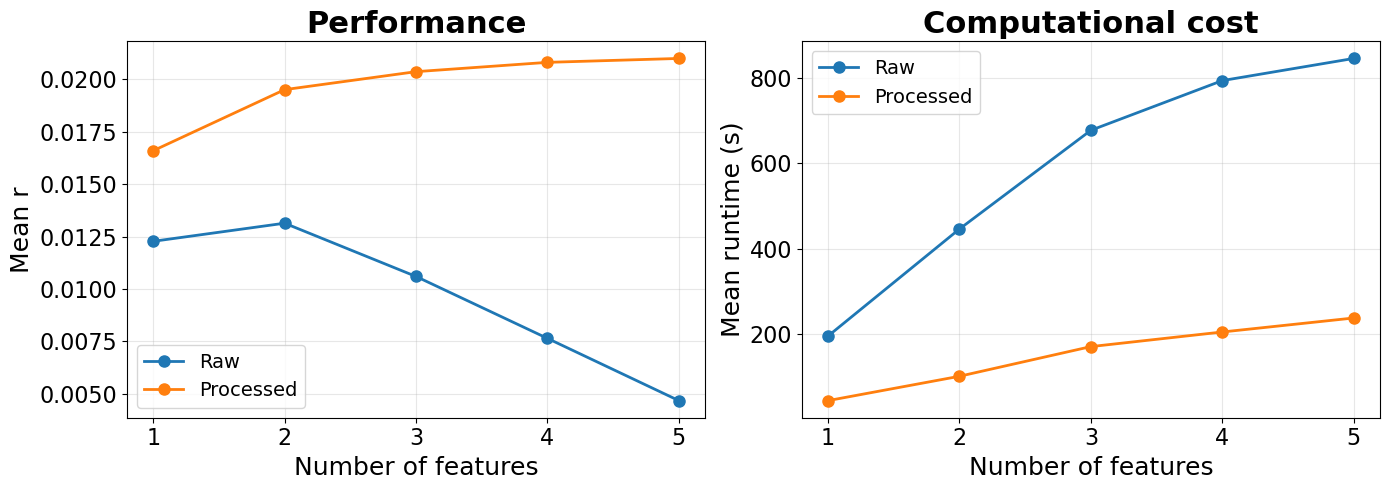

In [12]:
# Plot performance vs computational cost (mean r vs runtime) per number of features

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col_idx, metric in enumerate(['r', 't_run']):
    ax = axes[col_idx]

    # Draw one line per pipeline
    for pipeline in ['not standardized', 'standardized']:
        pipeline_label = 'processed' if pipeline == 'standardized' else 'raw'
        enc_df = df[(df['direction'] == 'encoding') & (df['pipeline'] == pipeline)]
        
        per_n = []

        # For each number of features compute mean r and mean running time
        for n in range(1, 6):
            n_df = enc_df[enc_df['n_features'] == n]
            if metric == 'r':
                vals = n_df[TRIAL_COLS].values.flatten() # 1D array
                per_n.append(np.mean(vals))
            else:
                per_n.append(n_df['t_run'].mean())

        # One line per pipeline
        ax.plot(range(1, 6), per_n, marker='o', linewidth=2, markersize=8,label=pipeline_label.capitalize())

    # Set axis and tick labels for both plots
    ax.set_xlabel('Number of features', fontsize=18)
    ax.set_xticks(range(1, 6))
    ax.tick_params(axis='both', labelsize=16)

    # Faint grid
    ax.grid(True, alpha=0.3)

    # Fix legend font size
    ax.legend(fontsize=14)

    # Set correct title and y axis label
    if metric == 'r':
        ax.set_ylabel('Mean r', fontsize=18)
        ax.set_title('Performance', fontsize=22, fontweight='bold')
    else:
        ax.set_ylabel('Mean runtime (s)', fontsize=18)
        ax.set_title('Computational cost', fontsize=22, fontweight='bold')

plt.tight_layout()

# Save as a pdf for the thesis
fig.savefig(DATA_ROOT / 'encoding_performance_vs_runtime.pdf', bbox_inches='tight')

plt.show()

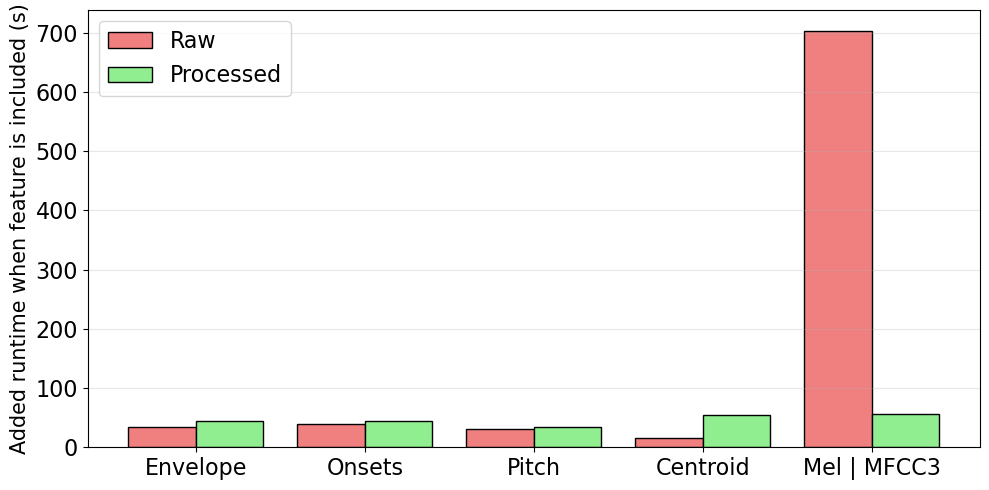

In [13]:
# Plot how much running time each feature adds when included in a combination (for both pipelines)

fig, ax = plt.subplots(figsize=(10, 5))

# 5 features along x axis (two bars per feature: raw and processed for the first four and mel and mfcc3 for the fifth)
x = np.arange(5) 

bar_width = 0.4

# Compute costs for both pipelines
for col_idx, pipeline in enumerate(['not standardized', 'standardized']):
    pipeline_label = 'processed' if pipeline == 'standardized' else 'raw'

    # Use different colors for the bars
    color = 'lightcoral' if pipeline == 'not standardized' else 'lightgreen'
    
    enc_df = df[(df['direction'] == 'encoding') & (df['pipeline'] == pipeline)]
    
    # Use the fixed feature order
    all_feats = FEAT_ORDERS[pipeline]
    
    # For each feature compute mean runtime when it is in the combo vs when it is not
    costs = []
    
    for feat in all_feats:
        
        # Mean runtime when feature is in the combo
        with_feat = enc_df[enc_df['combo_name'].apply(lambda c: feat in c.split('+'))]
        
        # Mean runtime when featture is not in the combo
        without_feat = enc_df[enc_df['combo_name'].apply(lambda c: feat not in c.split('+'))]
        
        # Difference (how much running time that feature adds)
        cost = with_feat['t_run'].mean() - without_feat['t_run'].mean()
        costs.append(cost)
    
    # Raw bar to the left, processed to the right (of the feature center)
    offset = -bar_width/2 if pipeline == 'not standardized' else bar_width/2
    ax.bar(x + offset, costs, bar_width, color=color, edgecolor='black', label=pipeline_label.capitalize())

# x axis ticks and labels
xtick_labels = ['Envelope', 'Onsets', 'Pitch', 'Centroid', 'Mel | MFCC3']
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=16)

# y axis ticks and labels
ax.set_ylabel('Added runtime when feature is included (s)', fontsize=15)
ax.tick_params(axis='y', labelsize=16)

# Faint horizontal grid
ax.grid(True, alpha=0.3, axis='y')

# Legend
ax.legend(fontsize=16)

plt.tight_layout()

# Save as a pdf for the thesis
fig.savefig(DATA_ROOT / 'feature_runtime_contribution.pdf', bbox_inches='tight')

plt.show()

In [14]:
# Mean runtime for encoding and decoding (with and without mel for raw pipeline)

print("Mean runtime per model fit in seconds")
print("-"*60)
print(f"{'Direction':<12} {'Pipeline':<15} {'Set':<13} {'Mean t_run':>12}")
print("-"*60)

# Compute mean t_run for both directions
for direction in ['decoding', 'encoding']:

    # For both pipelines
    for pipeline in ['not standardized', 'standardized']:
        sub = df[(df['direction'] == direction) & (df['pipeline'] == pipeline)]
        pipeline_label = 'processed' if pipeline == 'standardized' else 'raw'

        # Show raw with and without mel
        if pipeline == 'not standardized':
            all_mean = sub['t_run'].mean()
            no_mel = sub[~sub['combo_name'].str.contains('mel')]
            no_mel_mean = no_mel['t_run'].mean()
            print(f"{direction:<12} {pipeline_label:<15} {'all':<13} {all_mean:>12.2f}")
            print(f"{direction:<12} {pipeline_label:<15} {'without mel':<13} {no_mel_mean:>12.2f}")
        else:
            # Just one number (no mel here)
            mean = sub['t_run'].mean()
            print(f"{direction:<12} {pipeline_label:<15} {'all':<13} {mean:>12.2f}")
        
        print()

Mean runtime per model fit in seconds
------------------------------------------------------------
Direction    Pipeline        Set             Mean t_run
------------------------------------------------------------
decoding     raw             all                2926.87
decoding     raw             without mel        2084.93

decoding     processed       all                 906.75

encoding     raw             all                 549.51
encoding     raw             without mel         186.35

encoding     processed       all                 135.22



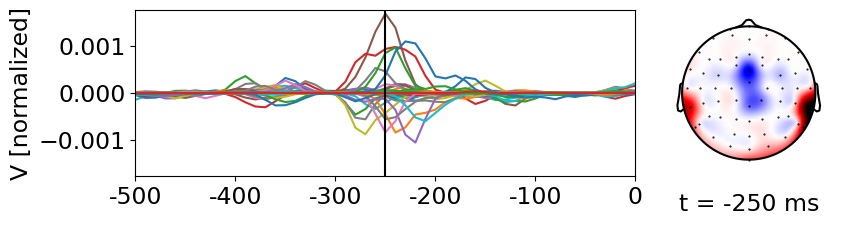

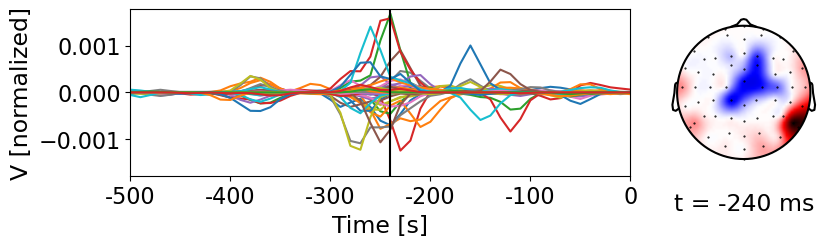

In [15]:
# Plot butterfly plot and topomaps of the mean musicians vs non-musicians TRF decoder for envelope (standardized pipeline, one band)

BAND = 'delta'
feat_name = 'envelope'

# Collect each subject's decoder kernel for this band
nm_trfs = []
m_trfs = []

for sub in range(1, 21):
    fpath = RESULTS_PROCESSED / f'Sub{sub}_{BAND}.pkl'
    if not fpath.exists():
        continue
    with open(fpath, 'rb') as f:
        data = pickle.load(f)

    # Search in decoding results
    res = data['decode_results'].get(feat_name)

    # Get the kernel
    h = res['model'].h
    
    # Subjects 1-10 are non-musicians and 11-20 are musicians
    if sub <= 10:
        nm_trfs.append(h)
    else:
        m_trfs.append(h)

# Group averages
combined_nm = combine(nm_trfs)
trf_avg_nm = combined_nm.mean('case')
combined_m = combine(m_trfs)
trf_avg_m = combined_m.mean('case')

# Find the maximum absolute value across both groups for consistent scaling
max_val = max(abs(trf_avg_nm).max(), abs(trf_avg_m).max()) * 1.05 # 5% more to not hit the edge

# Non-musicians plot
p_nm = eelbrain.plot.TopoButterfly(trf_avg_nm, t=-0.250, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.500, 0.000))

# Set font sizes and labels for non-musicians plot
for ax in p_nm.axes:
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=17)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)

# Musicians plot with same scaling
p_m = eelbrain.plot.TopoButterfly(trf_avg_m, t=-0.240, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.500, 0.000))

# Set font sizes and labels for musicians plot
for ax in p_m.axes:
    ax.set_xlabel('Time [s]', fontsize=17)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)
        
# Move head plots slightly to the right for non-musicians
for i, ax in enumerate(p_nm.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Move head plots slightly to the right for musicians
for i, ax in enumerate(p_m.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save both plots for the thesis
p_nm.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_non_musicians.pdf', bbox_inches='tight')
p_m.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_musicians.pdf', bbox_inches='tight')

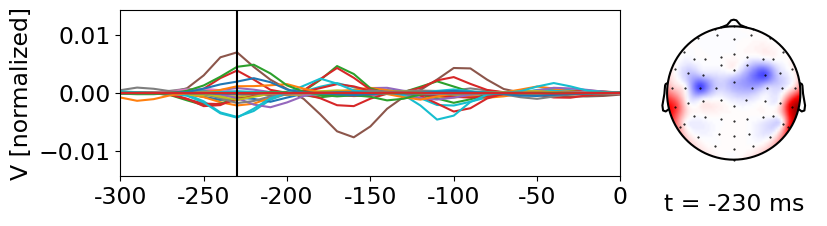

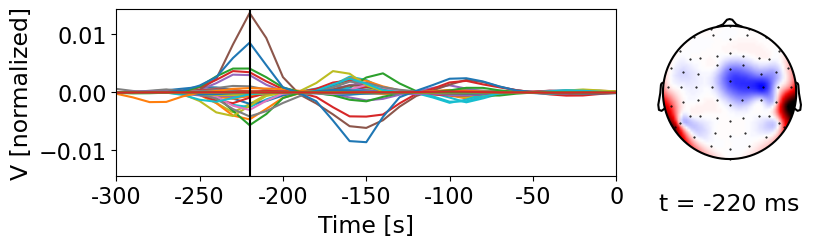

In [16]:
# Plot butterfly plot and topomaps of the mean musicians vs non-musicians TRF decoder for envelope (standardized pipeline, one band)

BAND = 'theta'
feat_name = 'envelope'

# Collect each subject's decoder kernel for this band
nm_trfs = []
m_trfs = []

for sub in range(1, 21):
    fpath = RESULTS_PROCESSED / f'Sub{sub}_{BAND}.pkl'
    if not fpath.exists():
        continue
    with open(fpath, 'rb') as f:
        data = pickle.load(f)

    # Search in decoding results
    res = data['decode_results'].get(feat_name)

    # Get the kernel
    h = res['model'].h
    
    # Subjects 1-10 are non-musicians and 11-20 are musicians
    if sub <= 10:
        nm_trfs.append(h)
    else:
        m_trfs.append(h)

# Group averages
combined_nm = combine(nm_trfs)
trf_avg_nm = combined_nm.mean('case')
combined_m = combine(m_trfs)
trf_avg_m = combined_m.mean('case')

# Find the maximum absolute value across both groups for consistent scaling
max_val = max(abs(trf_avg_nm).max(), abs(trf_avg_m).max()) * 1.05 # 5% more to not hit the edge

# Non-musicians plot
p_nm = eelbrain.plot.TopoButterfly(trf_avg_nm, t=-0.230, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.300, 0.000))

# Set font sizes and labels for non-musicians plot
for ax in p_nm.axes:
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=17)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)

# Musicians plot with same scaling
p_m = eelbrain.plot.TopoButterfly(trf_avg_m, t=-0.220, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.300, 0.000))

# Set font sizes and labels for musicians plot
for ax in p_m.axes:
    ax.set_xlabel('Time [s]', fontsize=17)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)
        
# Move head plots slightly to the right for non-musicians
for i, ax in enumerate(p_nm.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Move head plots slightly to the right for musicians
for i, ax in enumerate(p_m.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save both plots for the thesis
p_nm.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_non_musicians.pdf', bbox_inches='tight')
p_m.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_musicians.pdf', bbox_inches='tight')

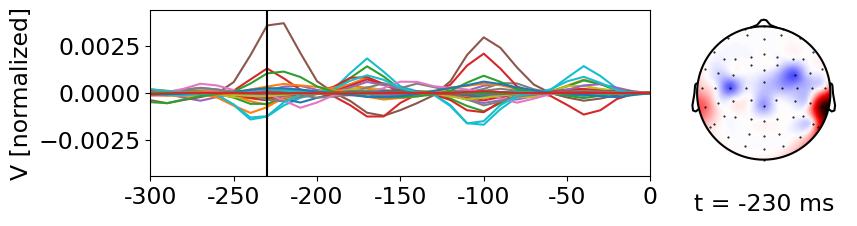

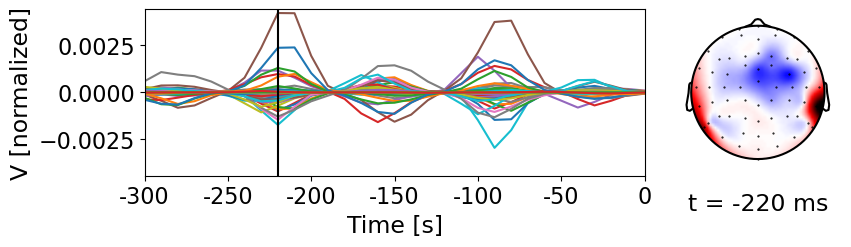

In [17]:
# Plot butterfly plot and topomaps of the mean musicians vs non-musicians TRF decoder for envelope (standardized pipeline, one band)

BAND = 'alpha'
feat_name = 'envelope'

# Collect each subject's decoder kernel for this band
nm_trfs = []
m_trfs = []

for sub in range(1, 21):
    fpath = RESULTS_PROCESSED / f'Sub{sub}_{BAND}.pkl'
    if not fpath.exists():
        continue
    with open(fpath, 'rb') as f:
        data = pickle.load(f)

    # Search in decoding results
    res = data['decode_results'].get(feat_name)

    # Get the kernel
    h = res['model'].h
    
    # Subjects 1-10 are non-musicians and 11-20 are musicians
    if sub <= 10:
        nm_trfs.append(h)
    else:
        m_trfs.append(h)

# Group averages
combined_nm = combine(nm_trfs)
trf_avg_nm = combined_nm.mean('case')
combined_m = combine(m_trfs)
trf_avg_m = combined_m.mean('case')

# Find the maximum absolute value across both groups for consistent scaling
max_val = max(abs(trf_avg_nm).max(), abs(trf_avg_m).max()) * 1.05 # 5% more to not hit the edge

# Non-musicians plot
p_nm = eelbrain.plot.TopoButterfly(trf_avg_nm, t=-0.230, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.300, 0.000))

# Set font sizes and labels for non-musicians plot
for ax in p_nm.axes:
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=17)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)

# Musicians plot with same scaling
p_m = eelbrain.plot.TopoButterfly(trf_avg_m, t=-0.220, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.300, 0.000))

# Set font sizes and labels for musicians plot
for ax in p_m.axes:
    ax.set_xlabel('Time [s]', fontsize=17)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)
        
# Move head plots slightly to the right for non-musicians
for i, ax in enumerate(p_nm.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Move head plots slightly to the right for musicians
for i, ax in enumerate(p_m.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save both plots for the thesis
p_nm.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_non_musicians.pdf', bbox_inches='tight')
p_m.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_musicians.pdf', bbox_inches='tight')

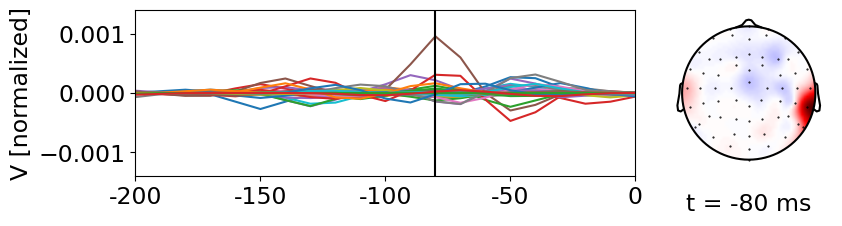

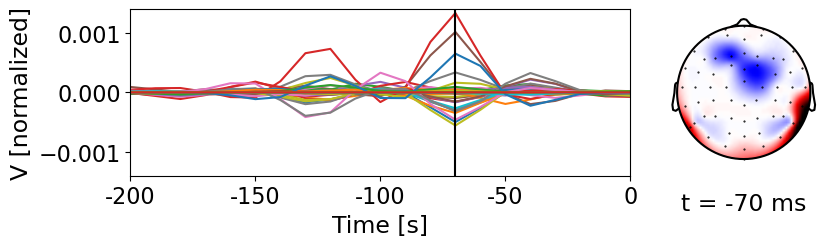

In [18]:
# Plot butterfly plot and topomaps of the mean musicians vs non-musicians TRF decoder for envelope (standardized pipeline, one band)

BAND = 'beta'
feat_name = 'envelope'

# Collect each subject's decoder kernel for this band
nm_trfs = []
m_trfs = []

for sub in range(1, 21):
    fpath = RESULTS_PROCESSED / f'Sub{sub}_{BAND}.pkl'
    if not fpath.exists():
        continue
    with open(fpath, 'rb') as f:
        data = pickle.load(f)

    # Search in decoding results
    res = data['decode_results'].get(feat_name)

    # Get the kernel
    h = res['model'].h
    
    # Subjects 1-10 are non-musicians and 11-20 are musicians
    if sub <= 10:
        nm_trfs.append(h)
    else:
        m_trfs.append(h)

# Group averages
combined_nm = combine(nm_trfs)
trf_avg_nm = combined_nm.mean('case')
combined_m = combine(m_trfs)
trf_avg_m = combined_m.mean('case')

# Find the maximum absolute value across both groups for consistent scaling
max_val = max(abs(trf_avg_nm).max(), abs(trf_avg_m).max()) * 1.05 # 5% more to not hit the edge

# Non-musicians plot
p_nm = eelbrain.plot.TopoButterfly(trf_avg_nm, t=-0.080, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.200, 0.000))

# Set font sizes and labels for non-musicians plot
for ax in p_nm.axes:
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=17)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)

# Musicians plot with same scaling
p_m = eelbrain.plot.TopoButterfly(trf_avg_m, t=-0.070, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.200, 0.000))

# Set font sizes and labels for musicians plot
for ax in p_m.axes:
    ax.set_xlabel('Time [s]', fontsize=17)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)
        
# Move head plots slightly to the right for non-musicians
for i, ax in enumerate(p_nm.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Move head plots slightly to the right for musicians
for i, ax in enumerate(p_m.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save both plots for the thesis
p_nm.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_non_musicians.pdf', bbox_inches='tight')
p_m.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_musicians.pdf', bbox_inches='tight')

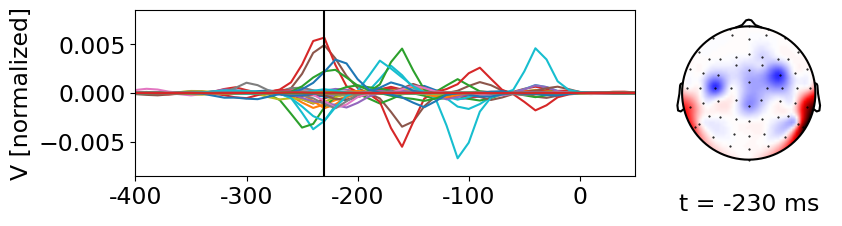

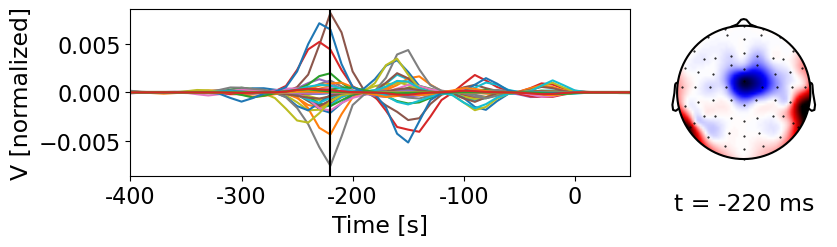

In [19]:
# Plot butterfly plot and topomaps of the mean musicians vs non-musicians TRF decoder for envelope (standardized pipeline, one band)

BAND = 'wideband'
feat_name = 'envelope'

# Collect each subject's decoder kernel for this band
nm_trfs = []
m_trfs = []

for sub in range(1, 21):
    fpath = RESULTS_PROCESSED / f'Sub{sub}_{BAND}.pkl'
    if not fpath.exists():
        continue
    with open(fpath, 'rb') as f:
        data = pickle.load(f)

    # Search in decoding results
    res = data['decode_results'].get(feat_name)

    # Get the kernel
    h = res['model'].h
    
    # Subjects 1-10 are non-musicians and 11-20 are musicians
    if sub <= 10:
        nm_trfs.append(h)
    else:
        m_trfs.append(h)

# Group averages
combined_nm = combine(nm_trfs)
trf_avg_nm = combined_nm.mean('case')
combined_m = combine(m_trfs)
trf_avg_m = combined_m.mean('case')

# Find the maximum absolute value across both groups for consistent scaling
max_val = max(abs(trf_avg_nm).max(), abs(trf_avg_m).max()) * 1.05 # 5% more to not hit the edge

# Non-musicians plot
p_nm = eelbrain.plot.TopoButterfly(trf_avg_nm, t=-0.230, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.400, 0.050))

# Set font sizes and labels for non-musicians plot
for ax in p_nm.axes:
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=17)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)

# Musicians plot with same scaling
p_m = eelbrain.plot.TopoButterfly(trf_avg_m, t=-0.220, w=7.5, h=2.5, clip='circle', vmax=max_val, vmin=-max_val, xlim=(-0.400, 0.050))

# Set font sizes and labels for musicians plot
for ax in p_m.axes:
    ax.set_xlabel('Time [s]', fontsize=17)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylabel('V [normalized]', fontsize=17)
    # Set font size for the 't =' text
    for text in ax.texts:
        text.set_fontsize(17)
        
# Move head plots slightly to the right for non-musicians
for i, ax in enumerate(p_nm.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Move head plots slightly to the right for musicians
for i, ax in enumerate(p_m.axes):
    if i > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0 + 0.04, pos.y0, pos.width, pos.height])

# Save both plots for the thesis
p_nm.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_non_musicians.pdf', bbox_inches='tight')
p_m.figure.savefig(DATA_ROOT / f'{feat_name}_{BAND}_musicians.pdf', bbox_inches='tight')

In [20]:
# All encoding feature combinations ranked by mean r per band for both pipelines

for pipeline in ['not standardized', 'standardized']:
    enc_df = df[(df['direction'] == 'encoding') & (df['pipeline'] == pipeline)]

    # Combinations ranked for each band
    for band in BANDS:
        band_df = enc_df[enc_df['band'] == band]
        
        combo_means = []
        for combo in band_df['combo_name'].unique(): # in total: 31 combinations
            
            # Get one combo
            combo_df = band_df[band_df['combo_name'] == combo]

            # Make 1D array for all trial values
            all_r = combo_df[TRIAL_COLS].values.flatten()

            # Add mean r and number of features in the combo
            combo_means.append((combo, np.mean(all_r), len(combo.split('+'))))

        # Sort mean r's in order to rank them
        combo_means.sort(key=lambda x: x[1], reverse=True) # reverse because of descending order

        # Print the results
        pipeline_label = 'processed' if pipeline == 'standardized' else 'raw'
        print(f'\n  {band} — {pipeline_label}')
        print(f'  {"Combo":<45} {"n_feat":>6} {"mean_r":>10}')
        print(f'  {"-" * 64}')
        for combo, mean_r, n in combo_means:
            print(f'  {combo:<45} {n:>6} {mean_r:>10.4f}')


  delta — raw
  Combo                                         n_feat     mean_r
  ----------------------------------------------------------------
  onsets+pitch+centroid                              3     0.0115
  onsets+centroid                                    2     0.0115
  onsets+pitch                                       2     0.0113
  onsets                                             1     0.0113
  envelope+onsets                                    2     0.0100
  envelope                                           1     0.0097
  envelope+onsets+pitch                              3     0.0095
  envelope+onsets+centroid                           3     0.0092
  envelope+onsets+pitch+centroid                     4     0.0092
  envelope+pitch                                     2     0.0092
  envelope+centroid                                  2     0.0088
  envelope+pitch+centroid                            3     0.0088
  pitch+centroid                                     2     0